> **Legacy notebook:** this is the pre-Figure-13 tracking notebook. Its saved outputs are historical; the paper-style comparison is in the new raco_visualization.ipynb.
> The old tracking run is not rerun as part of the visualization correction.


# XFeat + RaCo-inspired heads：ranker・detector・covarianceの実出力

公開済みbestモデルを使い、特徴点の選択、異方性のある位置共分散、連続フレーム間の対応を可視化する。
同じXFeat候補・descriptorに対して **detector順 / learned rank順の各512点** を比較する。

**データ:** [TUM RGB-D](https://cvg.cit.tum.de/data/datasets/rgbd-dataset)、[CC BY 4.0](https://creativecommons.org/licenses/by/4.0/)。
J. Sturm, N. Engelhard, F. Endres, W. Burgard, D. Cremers, *A Benchmark for the Evaluation of RGB-D SLAM Systems*, IROS 2012。
`freiburg3_nostructure_texture_far` と `freiburg3_structure_texture_far` の画像を使用し、色map・特徴点・対応線を重ねている。

**モデル:** [rgbd-raco-v1 Release](https://github.com/yuki-inaho/accelerated_features/releases/tag/rgbd-raco-v1)
の `xfeat-raco-rgbd-best.pt`（固定XFeat本体にrank/covariance headを追加した実装）。
取得時にはモデルとデータarchiveのSHA-256を照合する。

## 再実行

このNotebookと `scripts/raco_visualization.py` があるリポジトリで実行する。
保存済みの出力はダウンロードやGPUなしでも閲覧できる。再実行は初回に約700 MiBの公開データとモデルを取得し、`temp/raco_viz/` に保存する。
Python 3.12、プロジェクトの `uv.lock` とeval依存を使用する。以下はリポジトリルートからの全セル実行例。

```bash
uv run --frozen --group eval --with nbformat==5.10.4 --with nbclient==0.10.2 --with ipykernel==6.30.1 python - <<'PY'
import sys
from pathlib import Path
import nbformat
from nbclient import NotebookClient
from jupyter_client import KernelManager
path = Path("notebooks/raco_visualization.ipynb")
nb = nbformat.read(path, as_version=4)
km = KernelManager(kernel_name="python3")
km.kernel_spec.argv = [sys.executable, "-m", "ipykernel_launcher", "-f", "{connection_file}"]
try:
    NotebookClient(nb, km=km, timeout=600, record_timing=False).execute()
finally:
    if km.has_kernel:
        km.shutdown_kernel(now=True)
nbformat.write(nb, path)
PY
```

下の `DEVICE` は今回の実行では `cuda`。GPUがない場合は `cpu` に変更する。演算はFP32。
描画には実数値を使い、推論出力の加工は表示用の色変換・楕円の倍率・注釈に限る。

In [1]:
from pathlib import Path
import json
import platform
import sys

import cv2
import matplotlib
matplotlib.use("Agg")
import numpy as np
import torch
from IPython.display import Image, Markdown, display

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
assert (ROOT / "scripts/raco_visualization.py").is_file(), "Open from the repository root or notebooks directory"
sys.path.insert(0, str(ROOT))

from modules.raco import XFeatRaCo
from scripts.raco_visualization import (
    FRAME_INDICES, MODEL_NAME, MODEL_SHA, SEQUENCES, dense_fields, evaluate_sequence,
    extract_frame, file_sha, image_tensor, load_frames, prepare_data,
    render_matches, render_pipeline, render_survival, render_tracks, save_metrics,
)

DEVICE = "cuda"  # Change to "cpu" when CUDA is unavailable.
TOP_K = 512
SEED = 20260927
WORK = ROOT / "temp/raco_viz"
OUTPUT = WORK / "results"
OUTPUT.mkdir(parents=True, exist_ok=True)
torch.manual_seed(SEED)
torch.set_num_threads(4)
assert DEVICE != "cuda" or torch.cuda.is_available(), "Set DEVICE to cpu to run without CUDA"

def show(paths):
    for path in paths:
        display(Image(data=path.read_bytes()))

print(json.dumps({"python": platform.python_version(), "torch": torch.__version__,
                  "numpy": np.__version__, "opencv": cv2.__version__,
                  "matplotlib": matplotlib.__version__, "device": DEVICE,
                  "gpu": torch.cuda.get_device_name(0) if DEVICE == "cuda" else None,
                  "seed": SEED, "top_k": TOP_K}, indent=2))

{
  "python": "3.12.12",
  "torch": "2.14.0+cu130",
  "numpy": "2.5.3",
  "opencv": "4.14.0",
  "matplotlib": "3.11.2",
  "device": "cuda",
  "gpu": "NVIDIA GeForce RTX 2070",
  "seed": 20260927,
  "top_k": 512
}


## 入力と固定条件

時刻順RGBの0始まりindex **90, 93, …, 180** の31枚/系列、隣接30組を使用する。主図はindex105、対応図は105→108。
入力は640×480のRGB（0–1、resizeなし）。モデルbundleの候補上限8192、keypoint probability閾値0.05、NMS 5×5、border4を使う。
候補とdescriptorは各フレームで一度計算し、2方式で共有する。rankが負の候補も除外しない。

Depth・poseはRGB時刻に最も近いサンプルを使用する。各時刻差が20 ms以内のときだけGT診断を行い、それ以外でもRGB追跡は継続する。
[公式ファイル形式](https://cvg.cit.tum.de/data/datasets/rgbd-dataset/file_formats)に従い、depthはPNG値/5000 [m]、0は欠測。
Freiburg3は歪み補正済みで、$K=\left[\begin{smallmatrix}535.4&0&320.1\\0&539.2&247.6\\0&0&1\end{smallmatrix}\right]$。
Poseはcamera-to-world $T_{WC}$、フレームAからBへの変換は $T_{BA}=T_{WB}^{-1}T_{WA}$。

In [2]:
manifests = prepare_data(WORK)
assert file_sha(WORK / "models" / MODEL_NAME) == MODEL_SHA
model = XFeatRaCo.from_bundle(WORK / "models" / MODEL_NAME, device=DEVICE).eval()
frames_by_sequence = {sequence: load_frames(WORK, sequence) for sequence in SEQUENCES}
inputs = ["| Sequence | RGB frames | GT同期有効 frames | Archive SHA-256 |",
          "|---|---:|---:|---|"]
for sequence, frames in frames_by_sequence.items():
    assert [frame["index"] for frame in frames] == list(FRAME_INDICES)
    inputs.append(f"| {sequence} | {len(frames)} | {sum(f['synchronized'] for f in frames)} | `{SEQUENCES[sequence]}` |")
display(Markdown("\n".join(inputs)))
print("Model SHA-256:", MODEL_SHA)
print("Candidate settings:", json.dumps(model.bundle(trained_heads=["rank", "covariance"])["config"]))

Verified freiburg3_nostructure_texture_far: 31 frames


Verified freiburg3_structure_texture_far: 31 frames


| Sequence | RGB frames | GT同期有効 frames | Archive SHA-256 |
|---|---:|---:|---|
| freiburg3_nostructure_texture_far | 31 | 31 | `e4a921052d342fd52fac74509bb75f65149acbda3d31b25f36402041625fdba9` |
| freiburg3_structure_texture_far | 31 | 29 | `3f58c707f54c93b68fecd77293630e96a76d7b0f2703eb8ad9cff45ba4bbb81a` |

Model SHA-256: fd02f809283132b905b7ad151fcabfc0c8d8ad613ed12d3fda589764e48e2575
Candidate settings: {"candidate_limit": 8192, "detection_threshold": 0.05, "border": 4, "sigma_min": 0.05}


## Ranker → detector → covariance：実数値から描く図

- **Ranker map:** 学習した補正 $2\tanh(\delta)\in[-2,2]$。最終rankは候補集合内の $\log(p+10^{-8})$ を平均・分散で標準化（分散に $10^{-6}$ を加算）した値のtanhを加えた $[-3,3]$ のscore。繰り返し検出の確率としては扱わない。
- **Detector map:** keypoint probability × reliability。値の範囲は[0,1]。弱い応答の表示にpower scale（γ=0.3）を使い、colorbarには元の値を記す。
- **Covariance maps:** $L=\left[\begin{smallmatrix}\operatorname{softplus}(a)&0\\b&\operatorname{softplus}(c)\end{smallmatrix}\right]$、$\Sigma=LL^T+0.05^2I$ [px²]。$\sigma_x,\sigma_y$ [px] と $\rho_{xy}=\Sigma_{xy}/(\sigma_x\sigma_y)$ を表示する。σの色範囲は[0,3]、ρは[-1,1]。
- **出力:** ranked top512の点色は最終rank score。楕円は画像4×4区画の各最高rank点、最大16点に描く。固有値 $\lambda_1,\lambda_2$ の楕円半軸は $\sqrt{5.991\lambda_i}$、向きは固有ベクトル。主図では軸を×4、中央cropでは×1とする。

楕円はGaussian仮定のnominal 95%形状で、校正済みの95%信頼区間とは限らない。
下のセルは主図フレームの全候補でdense表示とsparse headの値が一致することも確認する。

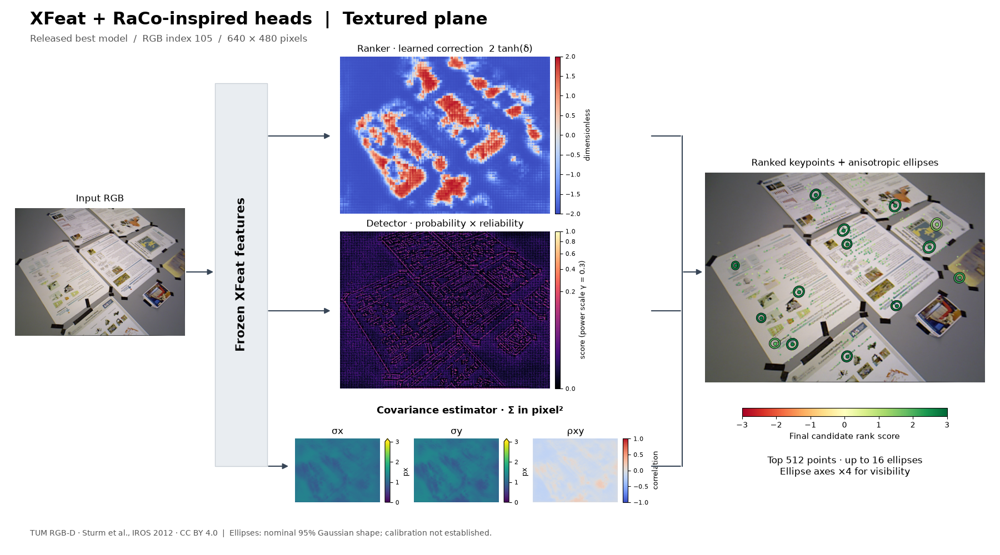

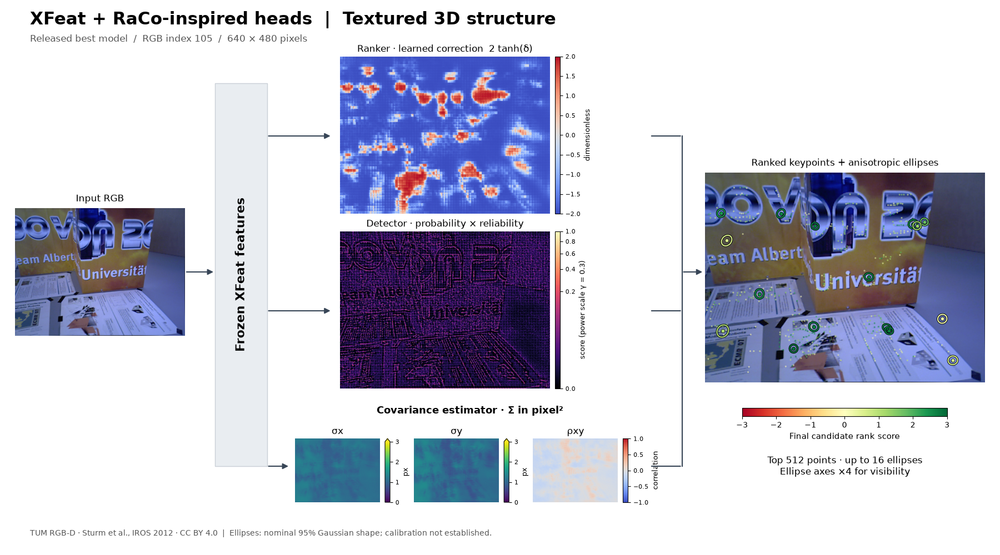

In [3]:
pipeline_paths, crop_paths = [], []
for sequence, frames in frames_by_sequence.items():
    frame = frames[5]
    tensor = image_tensor(frame["image"])
    fields = dense_fields(model, tensor)
    candidate = model.candidates(tensor)[0]
    with torch.no_grad():
        xy = candidate["keypoints"]
        correction = 2 * model.heads.ranker(candidate["z"], xy).squeeze(-1).tanh()
        covariance = model.heads.covariance(candidate["z"], xy)
    x, y = xy.T.cpu().numpy()
    np.testing.assert_allclose(fields["rank_correction"][y, x], correction.cpu().numpy(), atol=1e-5, rtol=1e-5)
    np.testing.assert_allclose(fields["covariance"][y, x], covariance.cpu().numpy(), atol=1e-5, rtol=1e-5)
    np.testing.assert_allclose(fields["detector"][y, x], candidate["scores"].cpu().numpy(), atol=1e-5)
    assert np.linalg.eigvalsh(fields["covariance"]).min() > 0
    prediction = extract_frame(model, frame["image"], top_k=TOP_K)["ranked"]
    pipeline, crop = render_pipeline(frame, fields, prediction, sequence, OUTPUT)
    pipeline_paths.append(pipeline)
    crop_paths.append(crop)
show(pipeline_paths)

### 楕円を元のpixel単位で見る

固定した中央領域 x=160–480, y=120–360。画像と楕円を同じ倍率で拡大表示し、共分散の軸長は元のpixel単位を保つ（×1）。

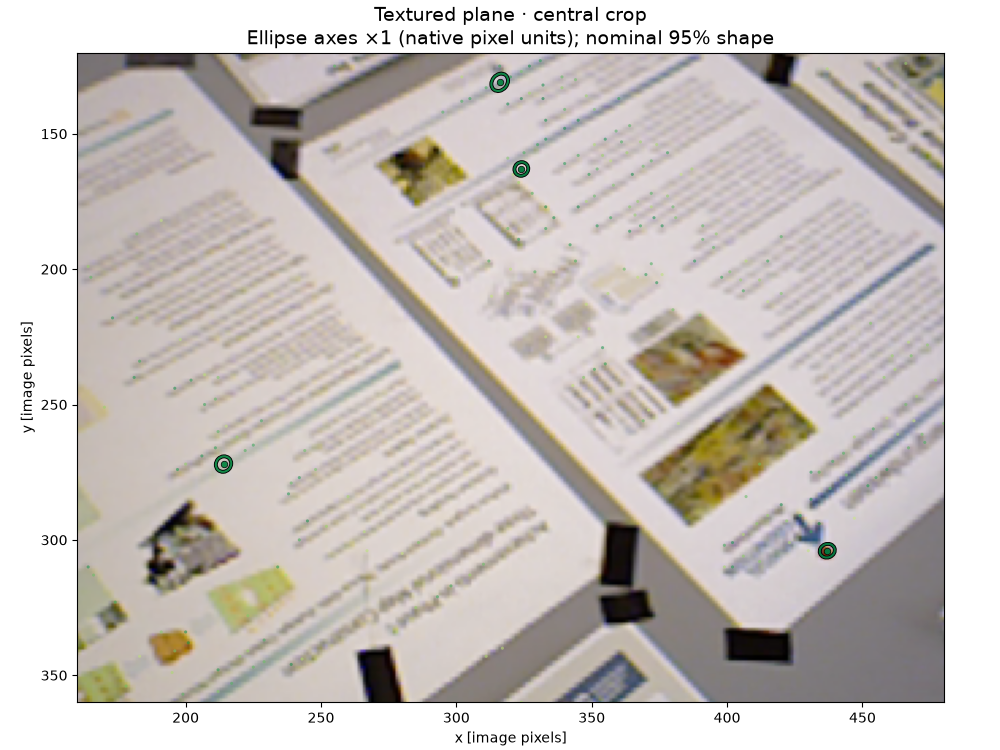

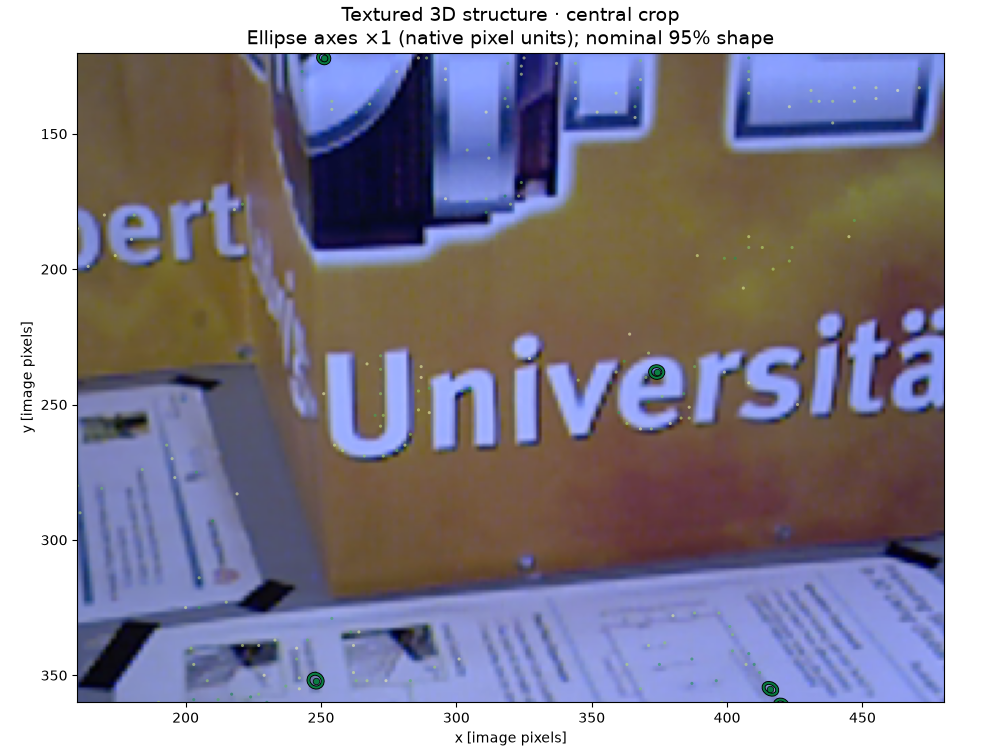

In [4]:
show(crop_paths)

## 隣接対応と初期trackの比較

DescriptorをL2正規化し、cosine **相互最近傍(MNN) ≥0.8** を対応とする。同値は選択indexの小さい方を優先する。
Track IDは最初の512点だけに付け、隣接対応を介して伝播する。途切れたIDは終了し、再開・新規追加はしない。GTはtrack構築に使用しない。

**GT診断:** source depthから逆投影し、$T_{BA}$と$K$でtargetへ投影する。両方向ともdepth有効、正のz、投影点が画像内、予測zとtarget depthの差が $\max(0.05\ \mathrm{m},0.05z)$ 以下の対応をeligibleとする。両方向の再投影誤差の最大値が **≤3 px** ならcorrect。
Depthは最近傍pixelで参照する。同期不適合frameに接する組はeligible=0、precisionは欠測。

表の正解率は全30組を合算した **Σcorrect / Σeligible**。平均対応数は全match数/30、誤差中央値は全eligible対応の最大双方向誤差の中央値。
除外された対応は正解率の分母に含めない。GT・depth・同期誤差を含む局所診断であり、姿勢精度の評価は行わない。

In [5]:
results = {}
for sequence, frames in frames_by_sequence.items():
    results[sequence] = evaluate_sequence(model, frames, sequence, OUTPUT, top_k=TOP_K)
summary = save_metrics(results, OUTPUT)
assert sum(len(result["rows"]) for result in results.values()) == 120
table = ["| Sequence | Selection | GT有効組/30 | Matches合計 | 平均/組 | Eligible | Correct | 正解率 | 誤差中央値 [px] | 最終track/512 |",
         "|---|---|---:|---:|---:|---:|---:|---:|---:|---:|"]
for row in summary:
    name = "nostructure" if "nostructure" in row["sequence"] else "structure"
    precision = f"{100*row['precision']:.2f}%" if row["precision"] is not None else "欠測"
    error = f"{row['median_error_px']:.3f}" if row["median_error_px"] is not None else "欠測"
    table.append(f"| {name} | {row['mode']} | {row['synchronized_edges']} | {row['matches']} | {row['mean_matches']:.1f} | {row['eligible']} | {row['correct']} | {precision} | {error} | {row['final_tracks']} |")
display(Markdown("\n".join(table)))

| Sequence | Selection | GT有効組/30 | Matches合計 | 平均/組 | Eligible | Correct | 正解率 | 誤差中央値 [px] | 最終track/512 |
|---|---|---:|---:|---:|---:|---:|---:|---:|---:|
| nostructure | detector | 30 | 6932 | 231.1 | 6419 | 3142 | 48.95% | 3.061 | 0 |
| nostructure | ranked | 30 | 9473 | 315.8 | 9359 | 5206 | 55.63% | 2.721 | 1 |
| structure | detector | 26 | 6401 | 213.4 | 5158 | 3558 | 68.98% | 2.012 | 0 |
| structure | ranked | 26 | 9707 | 323.6 | 8171 | 6108 | 74.75% | 2.014 | 2 |

### 固定ペアの対応

各方式の選択index順で先頭80対応を描く。全対応数は図題に記載。緑はGT診断≤3 px、赤は>3 px、灰色はGT診断不可。

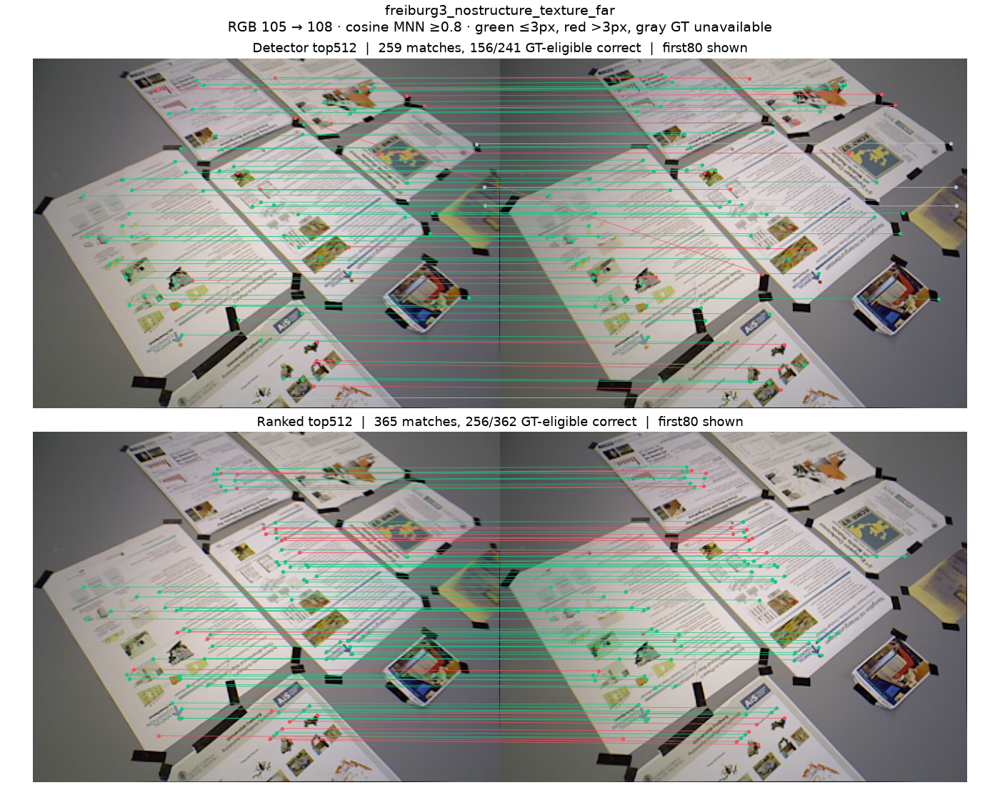

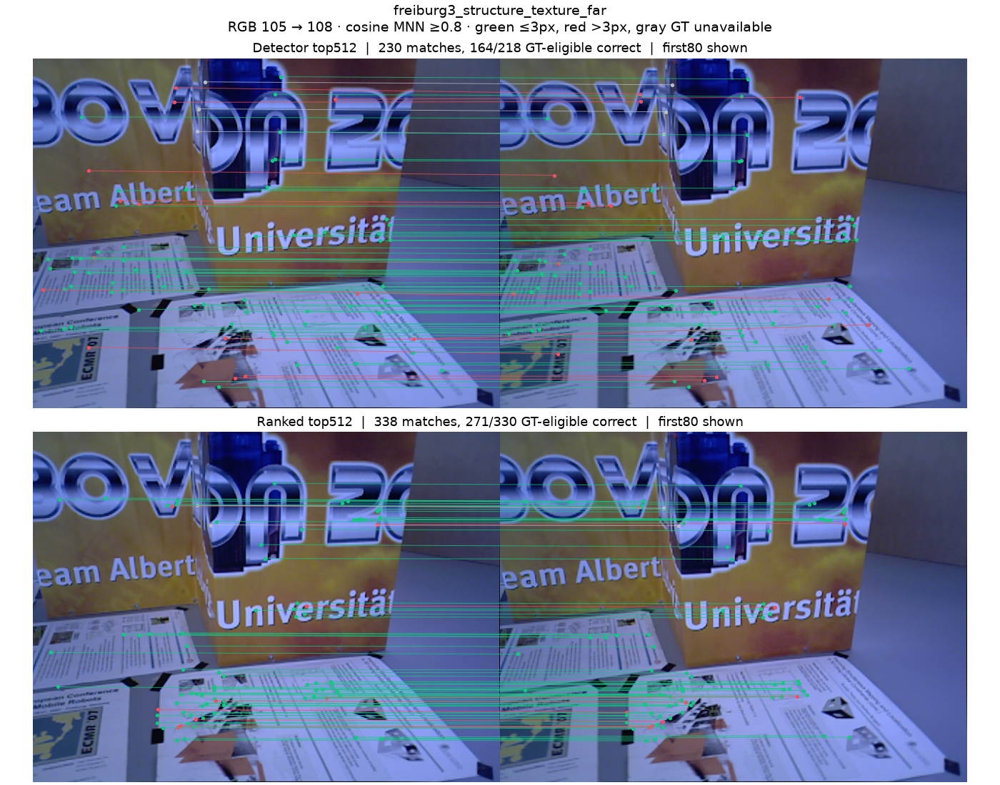

In [6]:
match_paths = [render_matches(result, sequence, OUTPUT) for sequence, result in results.items()]
show(match_paths)

### Trackの推移

RGB index90 / 120 / 150 / 180で、初期ID 0–15のうち生存している点と直近最大8フレームの軌跡を示す。
ID番号は各方式の初期選択順であり、方式間で同じ番号が同じ物理点を表すとは限らない。各panelの生存数と曲線は初期512点すべてを集計する。
途切れたtrackの過去の線は、以後のpanelには描かない。

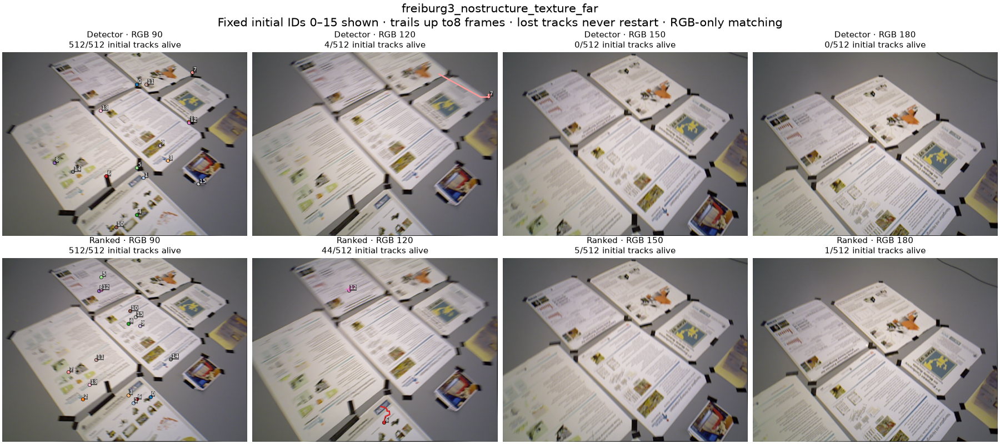

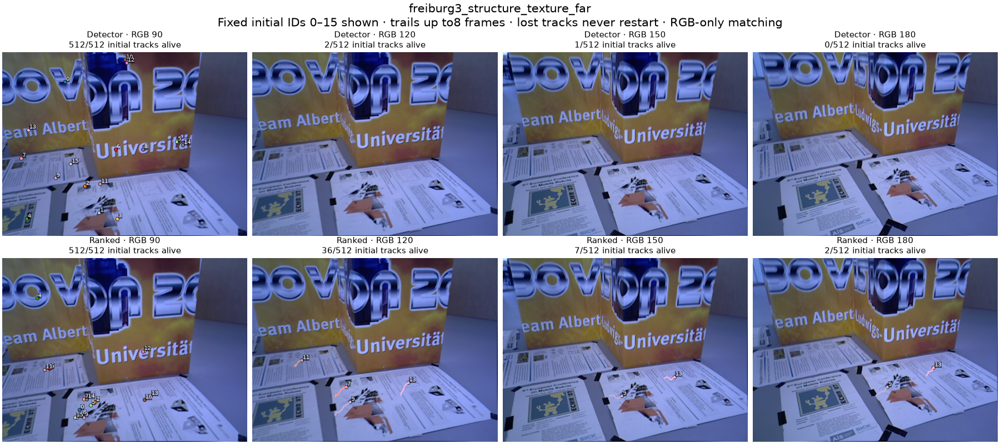

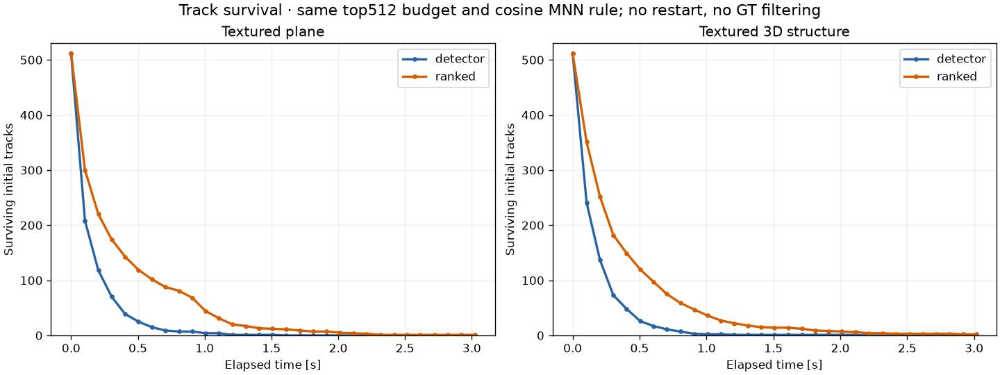

In [7]:
track_paths = [render_tracks(result, sequence, OUTPUT) for sequence, result in results.items()]
survival_path = render_survival(results, OUTPUT)
show(track_paths + [survival_path])

## 結果の読み方

この固定した短区間では、ranked選択で平均対応数とGT診断の正解率が増えた。共通の候補とdescriptorを使っているため、ここでの差は選択順位による。
この生存数には、カメラ移動による可視性の変化、各フレームでのtop512の選び直し、一度途切れたら終了する条件が含まれる。移動や可視性を分離した追跡性能の評価は行っていない。
構造のある系列のGT診断は、同期条件を満たさない2フレームに接する4組を除いた26組である。
共分散の校正や他の場面への一般化は、この可視化からは判断しない。

PNG、120行の `metrics.csv`、集計 `summary.json`、全初期IDの座標 `*_tracks.npz` は `temp/raco_viz/results/` に保存される。
以下に、この実行の入力・helper・画像の照合値を保存する。

In [8]:
artifacts = pipeline_paths + crop_paths + match_paths + track_paths + [survival_path]
provenance = {
    "model": MODEL_NAME, "model_sha256": MODEL_SHA,
    "archive_sha256": SEQUENCES, "frame_indices": list(FRAME_INDICES),
    "seed": SEED, "device": DEVICE, "top_k": TOP_K,
    "helper_sha256": file_sha(ROOT / "scripts/raco_visualization.py"),
    "figures_sha256": {path.name: file_sha(path) for path in artifacts},
}
(OUTPUT / "provenance.json").write_text(json.dumps(provenance, indent=2) + "\n")
print(f"Saved {len(artifacts)} rendered PNGs and 120 metric rows.")
print("Helper SHA-256:", provenance["helper_sha256"])
for sequence in SEQUENCES:
    base, ranked = [row for row in summary if row["sequence"] == sequence]
    print(f"{sequence}: matches/edge {base['mean_matches']:.1f} → {ranked['mean_matches']:.1f}; "
          f"eligible precision {100*base['precision']:.2f}% → {100*ranked['precision']:.2f}%; "
          f"final tracks {base['final_tracks']} → {ranked['final_tracks']}")

Saved 9 rendered PNGs and 120 metric rows.
Helper SHA-256: ec2c7a5664f4b16c74da83250abf0b2370f7d0592aff9c838aae7c7ccbd44bf4
freiburg3_nostructure_texture_far: matches/edge 231.1 → 315.8; eligible precision 48.95% → 55.63%; final tracks 0 → 1
freiburg3_structure_texture_far: matches/edge 213.4 → 323.6; eligible precision 68.98% → 74.75%; final tracks 0 → 2
